# Module 2 — Logistic Regression

Classificazione del **Severity Impairment Index (`sii`)** sul dataset CMI, a valle dei moduli 0
(data understanding e preparation) e 1 (outlier detection).

**Struttura**
1. Caricamento dati e definizione del task
2. Split train/test e pipeline di preprocessing
3. Modello di base e ruolo di `class_weight`
4. Hyper-parameter tuning (validation curve su `C`, grid search L1/L2)
5. Valutazione del modello finale a 4 classi
6. Interpretazione dei coefficienti (odds ratio)
7. Target binario `sii >= 1` e scelta della soglia
8. Confronto diretto fra le due formulazioni
9. Un secondo target: le ore di internet (multi-classe e binario)
10. Conclusioni

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve, roc_auc_score)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (7, 5)

## 1. Caricamento dati e definizione del task

Il task richiesto dalle guidelines è multi-classe: predire `sii` ∈ {0, 1, 2, 3} dalle variabili
antropometriche, di fitness, di composizione corporea e dai questionari.

Le colonne `PCIAT-*` sono già state eliminate nel Module 0 per *target leakage* (`sii` è ottenuto
dalle fasce di `PCIAT-PCIAT_Total`), quindi qui si usano tutte le colonne rimaste tranne `id`.

In [35]:
df = pd.read_csv('cmi_internet_final.csv')
print('Shape:', df.shape, '| valori mancanti:', df.isna().sum().sum())

y = df['sii']
X = df.drop(columns=['id', 'sii'])

cat_cols = [c for c in X.columns if 'Season' in c]          # categoriche nominali (stringa)
num_cols = [c for c in X.columns if c not in cat_cols]      # continue + ordinali gia' numeriche
print(f'{len(num_cols)} feature numeriche, {len(cat_cols)} categoriche')

dist = y.value_counts().sort_index()
print('\nDistribuzione del target:')
print(pd.DataFrame({'n': dist, '%': (dist / len(y) * 100).round(2)}))

Shape: (8460, 50) | valori mancanti: 0
38 feature numeriche, 10 categoriche

Distribuzione del target:
        n      %
sii             
0    5833  68.95
1    1587  18.76
2     952  11.25
3      88   1.04


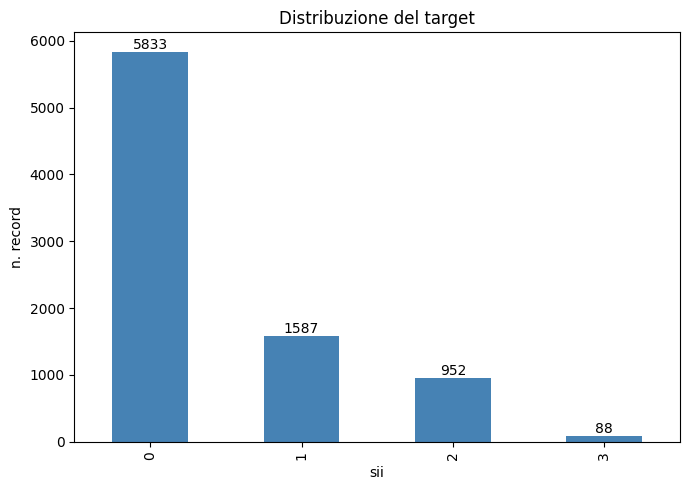

In [36]:
ax = dist.plot(kind='bar', color='steelblue')
ax.set_xlabel('sii'); ax.set_ylabel('n. record'); ax.set_title('Distribuzione del target')
for i, v in enumerate(dist):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 2. Split train/test e pipeline di preprocessing

**Scelte e motivazioni**

- **`stratify=y`**: con 87 record di classe 3 su 8445, uno split non stratificato può produrre proporzioni
  molto diverse fra train e test. La stratificazione le mantiene.
- **`StandardScaler`**: la regressione logistica regolarizzata non è invariante alla scala, perché la
  penalità agisce sulla norma dei coefficienti. Senza standardizzazione una feature con valori grandi
  (`BIA-BIA_DEE`, migliaia di kcal) verrebbe penalizzata più di una con valori piccoli (`PAQ_C_Total`, 1-5).
  Serve anche a rendere i coefficienti confrontabili in fase di interpretazione.
- **`OneHotEncoder(drop='first')`**: le colonne `Season` sono nominali. Si elimina una categoria per
  evitare la collinearità perfetta con l'intercetta.
- **Tutto dentro una `Pipeline`**: scaler ed encoder vengono fittati solo sul train, anche dentro ogni fold
  della cross-validation. È lo stesso principio del notebook di lezione (`fit_transform` sul train,
  `transform` sul test) esteso automaticamente alla CV, così da evitare data leakage.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('\nProporzioni train/test (controllo della stratificazione):')
print(pd.DataFrame({'train %': (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
                    'test %':  (y_test.value_counts(normalize=True).sort_index() * 100).round(2)}))

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: (6768, 48) | Test: (1692, 48)

Proporzioni train/test (controllo della stratificazione):
     train %  test %
sii                 
0      68.94   68.97
1      18.76   18.74
2      11.26   11.23
3       1.03    1.06


### Metriche

Su un dataset così sbilanciato l'accuracy da sola è fuorviante: predire sempre la classe 0 dà già il 69%.

- **accuracy**: quota di predizioni corrette, dominata dalla classe maggioritaria.
- **balanced accuracy**: media delle recall per classe, tutte le classi pesano uguale.
- **F1-macro**: media non pesata delle F1 per classe. È la metrica usata per il tuning.
- **ROC AUC**: qualità del *ranking* delle probabilità, indipendente dalla soglia. Con più di due classi
  si calcola una curva per classe (`multi_class='ovr'` è il parametro che sklearn richiede per questo
  calcolo) e se ne fa la media.

In [38]:
def valuta(nome, modello, X_te=None, y_te=None, stampa=True):
    X_te = X_test if X_te is None else X_te
    y_te = y_test if y_te is None else y_te
    y_pred = modello.predict(X_te)
    y_prob = modello.predict_proba(X_te)
    res = {
        'modello': nome,
        'accuracy': accuracy_score(y_te, y_pred),
        'balanced_acc': balanced_accuracy_score(y_te, y_pred),
        'f1_macro': f1_score(y_te, y_pred, average='macro'),
        'roc_auc': roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro'),
    }
    if stampa:
        print(f'=== {nome} ===')
        print({k: round(v, 3) for k, v in res.items() if k != 'modello'})
        print(classification_report(y_te, y_pred, digits=3, zero_division=0))
    return res

risultati = []

## 3. Modello di base e ruolo di `class_weight`

Due riferimenti prima di commentare qualsiasi risultato:

1. **Classificatore banale** (`DummyClassifier`): predice sempre la classe più frequente. Non produce
   probabilità utili, quindi per esso non ha senso calcolare una ROC AUC (varrebbe 0.5 per costruzione);
   serve solo come soglia minima di accuracy.
2. **Regressione logistica di default**: penalità L2, `C=1`, nessun peso sulle classi.

Poi si confronta con `class_weight='balanced'`, che pesa ogni classe in modo inversamente proporzionale
alla sua frequenza, dando quindi più importanza agli errori sulle classi rare nella funzione di costo.

In [39]:
dummy = Pipeline([('prep', preprocessor),
                  ('clf', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print('Dummy -> accuracy', round(accuracy_score(y_test, y_dummy), 3),
      '| F1-macro', round(f1_score(y_test, y_dummy, average='macro'), 3),
      '| ROC AUC: 0.5 per costruzione (nessun ranking)')

Dummy -> accuracy 0.69 | F1-macro 0.204 | ROC AUC: 0.5 per costruzione (nessun ranking)


=== LR base (L2, C=1, no weights) ===
{'accuracy': 0.685, 'balanced_acc': 0.281, 'f1_macro': 0.268, 'roc_auc': 0.709}
              precision    recall  f1-score   support

           0      0.712     0.961     0.818      1167
           1      0.312     0.047     0.082       317
           2      0.324     0.116     0.171       190
           3      0.000     0.000     0.000        18

    accuracy                          0.685      1692
   macro avg      0.337     0.281     0.268      1692
weighted avg      0.586     0.685     0.599      1692



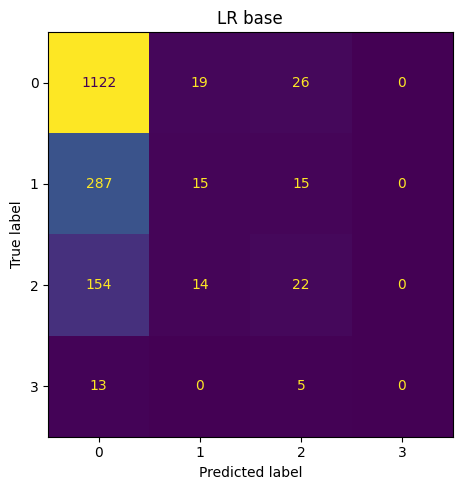

In [40]:
lr_base = Pipeline([('prep', preprocessor),
                    ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
lr_base.fit(X_train, y_train)
risultati.append(valuta('LR base (L2, C=1, no weights)', lr_base))
ConfusionMatrixDisplay.from_predictions(y_test, lr_base.predict(X_test), colorbar=False)
plt.title('LR base'); plt.tight_layout(); plt.show()

=== LR balanced (L2, C=1) ===
{'accuracy': 0.457, 'balanced_acc': 0.383, 'f1_macro': 0.304, 'roc_auc': 0.677}
              precision    recall  f1-score   support

           0      0.809     0.530     0.640      1167
           1      0.256     0.252     0.254       317
           2      0.228     0.363     0.280       190
           3      0.022     0.389     0.042        18

    accuracy                          0.457      1692
   macro avg      0.329     0.383     0.304      1692
weighted avg      0.632     0.457     0.521      1692



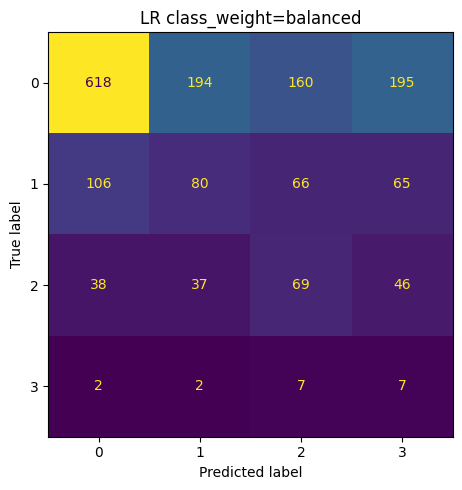

In [41]:
lr_bal = Pipeline([('prep', preprocessor),
                   ('clf', LogisticRegression(max_iter=5000, class_weight='balanced',
                                              random_state=RANDOM_STATE))])
lr_bal.fit(X_train, y_train)
risultati.append(valuta('LR balanced (L2, C=1)', lr_bal))
ConfusionMatrixDisplay.from_predictions(y_test, lr_bal.predict(X_test), colorbar=False)
plt.title('LR class_weight=balanced'); plt.tight_layout(); plt.show()

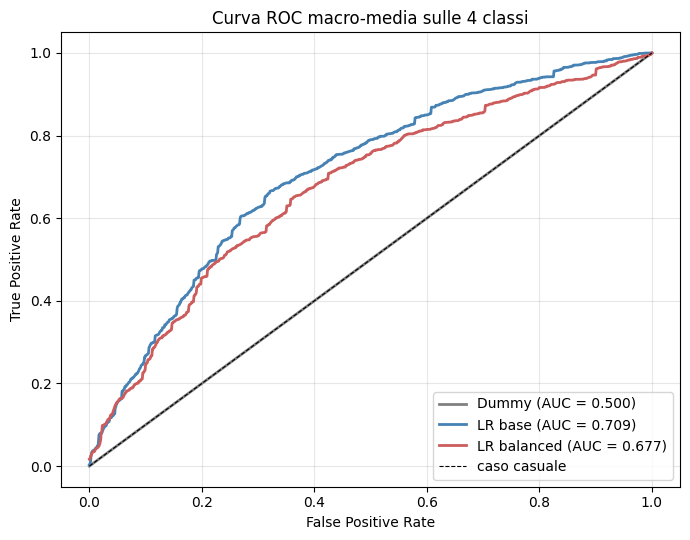

In [42]:
# Curva ROC macro-media: per ogni modello si calcolano le 4 curve per classe (classe k contro le altre),
# si interpolano su una griglia comune di FPR e si media il TPR. L'area sotto la curva risultante coincide
# con la media delle 4 AUC, cioe' con il valore riportato nella tabella dei risultati.
def roc_macro(modello, X_te=X_test, y_te=y_test, classi=(0, 1, 2, 3)):
    prob = modello.predict_proba(X_te)
    griglia_fpr = np.linspace(0, 1, 1001)
    tpr_medio = np.zeros_like(griglia_fpr)
    for k in classi:
        fpr_k, tpr_k, _ = roc_curve((y_te == k).astype(int), prob[:, k])
        tpr_medio += np.interp(griglia_fpr, fpr_k, tpr_k)
    tpr_medio /= len(classi)
    return griglia_fpr, tpr_medio

modelli_roc = [('Dummy', dummy, 'grey'),
               ('LR base', lr_base, 'steelblue'),
               ('LR balanced', lr_bal, 'indianred')]

plt.figure(figsize=(7, 5.5))
for nome, mod, colore in modelli_roc:
    fpr, tpr = roc_macro(mod)
    a = roc_auc_score(y_test, mod.predict_proba(X_test), multi_class='ovr', average='macro')
    plt.plot(fpr, tpr, color=colore, linewidth=2, label=f'{nome} (AUC = {a:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=.8, label='caso casuale')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curva ROC macro-media sulle 4 classi')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Osservazione chiave.** Il modello senza pesi ha accuracy quasi identica al dummy perché predice quasi
sempre la classe 0: le recall delle classi 1, 2 e 3 sono vicine a zero. Con `class_weight='balanced'`
l'accuracy crolla ma la balanced accuracy e le recall delle classi rare salgono: il modello inizia a
predirle, al prezzo di molti falsi positivi.

Le curve ROC aggiungono un'informazione che le matrici di confusione non danno: il dummy coincide con la
diagonale (AUC 0.5, nessuna capacità di ordinare i casi), mentre entrambe le regressioni logistiche stanno
sopra di essa. Il modello sa quindi ordinare i soggetti meglio del caso anche quando, con la soglia di
default, finisce per assegnarli quasi tutti alla classe 0: il limite sta nella soglia di decisione, non
solo nel modello. Si noti anche che `class_weight='balanced'` non migliora l'AUC — cambia le soglie
implicite, non la qualità del ranking.

È il trade-off centrale di questo task e va dichiarato nel report: non esiste una configurazione che
migliori tutte le metriche insieme. Qui si ottimizza **F1-macro**, perché le guidelines chiedono di
valutare tutte le classi e perché un modello che ignora le classi 1-3 non risponde alla domanda di ricerca.

## 4. Hyper-parameter tuning

| Parametro | Valori | Motivazione |
|---|---|---|
| `C` | 0.001 → 100 | Inverso della forza di regolarizzazione. `C` piccolo = modello più semplice (coefficienti vicini a 0, meno varianza), `C` grande = modello più aderente ai dati. |
| `penalty` | `l2`, `l1` | L2 restringe tutti i coefficienti, L1 può azzerarli facendo selezione delle feature. Interessante perché molte variabili BIA sono ridondanti. |
| `class_weight` | `None`, `balanced` | Gestione dello sbilanciamento. |
| `solver` | `lbfgs` (L2), `saga` (L1) | `lbfgs` non supporta L1; `saga` supporta entrambe ma è più lento. |

Si parte da una **validation curve** su `C`, che mostra l'effetto della regolarizzazione, poi si esegue
la grid search.

In [43]:
griglia_C = [0.001, 0.01, 0.1, 1, 10, 100]
curva = []
for cw in [None, 'balanced']:
    for C in griglia_C:
        pipe = Pipeline([('prep', preprocessor),
                         ('clf', LogisticRegression(max_iter=3000, C=C, class_weight=cw,
                                                    random_state=RANDOM_STATE))])
        s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
        curva.append({'class_weight': str(cw), 'C': C, 'f1_macro': s.mean(), 'std': s.std()})
curva = pd.DataFrame(curva)
print(curva.round(4).to_string(index=False))

class_weight       C  f1_macro    std
        None   0.001    0.2180 0.0063
        None   0.010    0.2485 0.0064
        None   0.100    0.2589 0.0086
        None   1.000    0.2647 0.0178
        None  10.000    0.2656 0.0173
        None 100.000    0.2652 0.0167
    balanced   0.001    0.3040 0.0153
    balanced   0.010    0.3045 0.0059
    balanced   0.100    0.3001 0.0065
    balanced   1.000    0.2955 0.0089
    balanced  10.000    0.2954 0.0082
    balanced 100.000    0.2955 0.0083


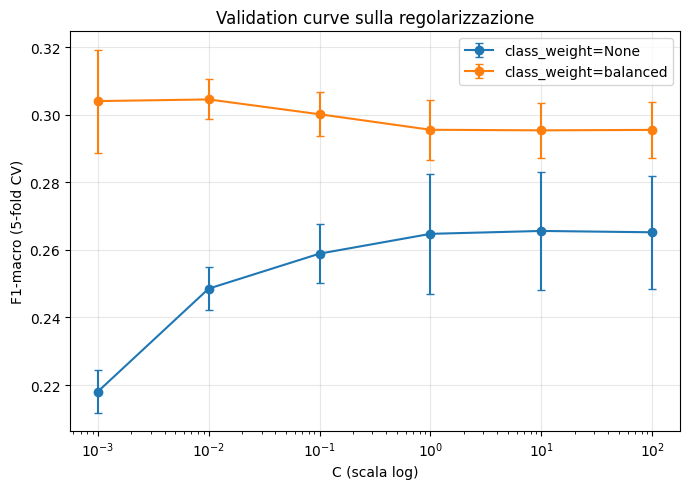

In [44]:
for cw, grp in curva.groupby('class_weight'):
    plt.errorbar(grp['C'], grp['f1_macro'], yerr=grp['std'], marker='o', capsize=3,
                 label=f'class_weight={cw}')
plt.xscale('log'); plt.xlabel('C (scala log)'); plt.ylabel('F1-macro (5-fold CV)')
plt.title('Validation curve sulla regolarizzazione'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [45]:
# Grid search L2 (solver lbfgs)
grid_l2 = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
    {'clf__C': griglia_C, 'clf__class_weight': [None, 'balanced']},
    scoring='f1_macro', cv=cv, n_jobs=-1)
grid_l2.fit(X_train, y_train)
print('Migliori parametri L2:', grid_l2.best_params_)
print('F1-macro in CV:', round(grid_l2.best_score_, 4))

Migliori parametri L2: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
F1-macro in CV: 0.3045


In [46]:
# Grid search L1 (solver saga). Piu' lenta: griglia ridotta ai valori promettenti.
grid_l1 = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', LogisticRegression(solver='saga', penalty='l1', max_iter=600, tol=1e-3,
                                         class_weight='balanced', random_state=RANDOM_STATE))]),
    {'clf__C': [0.001, 0.01, 0.1]},
    scoring='f1_macro', cv=cv, n_jobs=-1)
grid_l1.fit(X_train, y_train)
print('Migliori parametri L1:', grid_l1.best_params_)
print('F1-macro in CV:', round(grid_l1.best_score_, 4))

coef_l1 = grid_l1.best_estimator_.named_steps['clf'].coef_
print(f'Coefficienti azzerati da L1: {(coef_l1 == 0).sum()} su {coef_l1.size}')

Migliori parametri L1: {'clf__C': 0.1}
F1-macro in CV: 0.2899
Coefficienti azzerati da L1: 0 su 272


**Lettura del tuning.**

- Senza pesi di classe F1-macro *cresce* con `C`: il modello non riesce comunque a predire le classi rare,
  quindi la regolarizzazione forte non aiuta.
- Con `class_weight='balanced'` la curva è *decrescente*: il valore migliore è il `C` più piccolo. Significa
  che il segnale utile è debole e che, con poca regolarizzazione, il modello insegue rumore. Con 87 record
  di classe 3 e oltre 60 feature il problema dominante è la varianza, non il bias.
- L1 non porta vantaggi e azzera pochissimi coefficienti: l'informazione è distribuita su molte variabili
  deboli, non concentrata in poche forti, quindi non c'è un sottoinsieme sparso da selezionare.

## 5. Modello finale a 4 classi

In [47]:
C_best = grid_l2.best_params_['clf__C']
cw_best = grid_l2.best_params_['clf__class_weight']
print(f'Modello finale: LogisticRegression L2, C={C_best}, class_weight={cw_best}')

modello_finale = Pipeline([('prep', preprocessor),
                           ('clf', LogisticRegression(max_iter=3000, C=C_best,
                                                      class_weight=cw_best,
                                                      random_state=RANDOM_STATE))])
modello_finale.fit(X_train, y_train)
risultati.append(valuta(f'LR ottimizzata (C={C_best}, {cw_best})', modello_finale, stampa=False))

y_pred = modello_finale.predict(X_test)
y_prob = modello_finale.predict_proba(X_test)
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

Modello finale: LogisticRegression L2, C=0.01, class_weight=balanced
              precision    recall  f1-score   support

           0      0.811     0.547     0.653      1167
           1      0.259     0.230     0.244       317
           2      0.221     0.358     0.274       190
           3      0.025     0.444     0.048        18

    accuracy                          0.465      1692
   macro avg      0.329     0.395     0.305      1692
weighted avg      0.633     0.465     0.527      1692



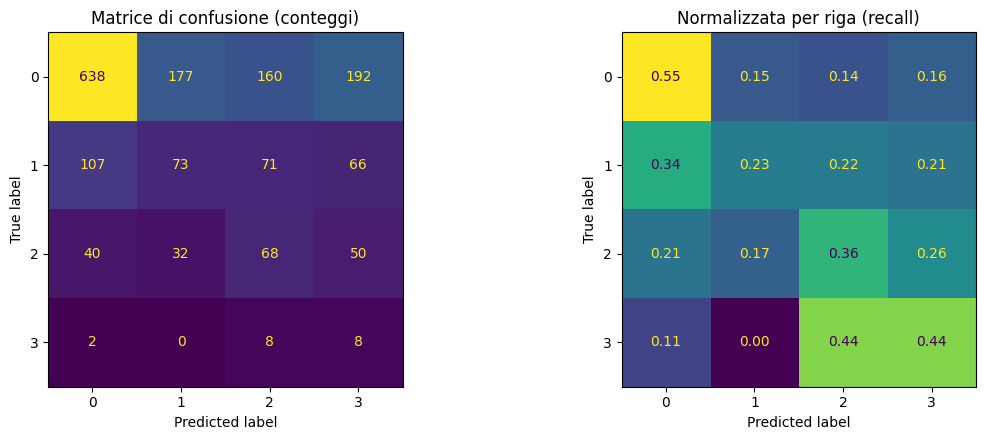

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Matrice di confusione (conteggi)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False,
                                        normalize='true', values_format='.2f')
axes[1].set_title('Normalizzata per riga (recall)')
plt.tight_layout(); plt.show()

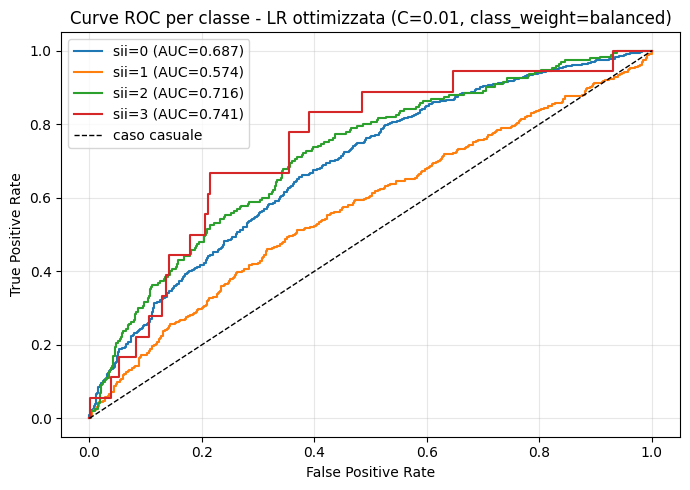

In [49]:
# Una curva ROC per ciascuna classe (classe k contro tutte le altre)
plt.figure(figsize=(7, 5))
for k in range(4):
    fpr, tpr, _ = roc_curve((y_test == k).astype(int), y_prob[:, k])
    plt.plot(fpr, tpr, label=f'sii={k} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='caso casuale')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'Curve ROC per classe - LR ottimizzata (C={C_best}, class_weight={cw_best})')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

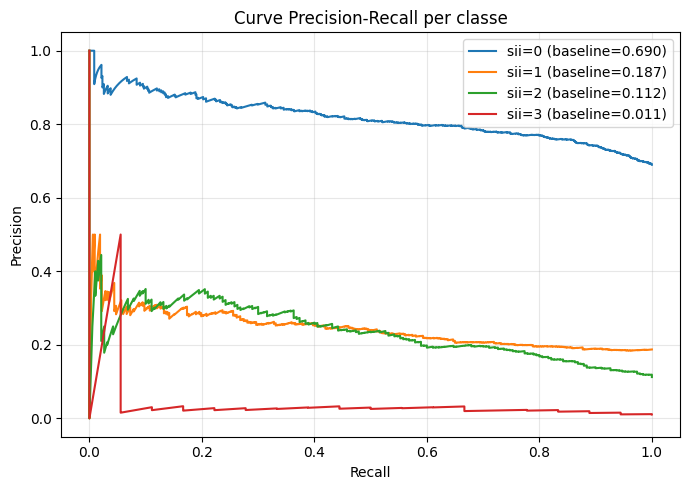

In [50]:
# Curve Precision-Recall: piu' informative della ROC quando le classi sono molto sbilanciate
plt.figure(figsize=(7, 5))
for k in range(4):
    prec, rec, _ = precision_recall_curve((y_test == k).astype(int), y_prob[:, k])
    base = (y_test == k).mean()
    plt.plot(rec, prec, label=f'sii={k} (baseline={base:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Curve Precision-Recall per classe')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [51]:
riepilogo = pd.DataFrame(risultati).round(3)
print(riepilogo.to_string(index=False))

                          modello  accuracy  balanced_acc  f1_macro  roc_auc
    LR base (L2, C=1, no weights)     0.685         0.281     0.268    0.709
            LR balanced (L2, C=1)     0.457         0.383     0.304    0.677
LR ottimizzata (C=0.01, balanced)     0.465         0.395     0.305    0.680


## 6. Interpretazione dei coefficienti

È il punto di forza della regressione logistica rispetto a SVM e reti neurali: i coefficienti sono leggibili.
Con quattro classi `LogisticRegression` stima un vettore di coefficienti per ciascuna. Dato che le feature
sono standardizzate, e^β si legge come: **di quanto vengono moltiplicati gli odds di appartenere a quella
classe quando la variabile aumenta di una deviazione standard**, a parità di tutte le altre.

Si commentano solo le feature numeriche: le dummy delle stagioni derivano in buona parte da imputazione
e i loro coefficienti non hanno una lettura sostantiva.

In [52]:
nomi = modello_finale.named_steps['prep'].get_feature_names_out()
coef = pd.DataFrame(modello_finale.named_steps['clf'].coef_.T, index=nomi,
                    columns=[f'sii={k}' for k in range(4)])
odds = np.exp(coef)

num_mask = [not n.startswith('cat__') for n in coef.index]
coef_num, odds_num = coef[num_mask], odds[num_mask]

for k in [0, 3]:
    top = coef_num[f'sii={k}'].abs().sort_values(ascending=False).head(10).index
    print(f'\n--- Odds ratio, 10 feature piu\' influenti per sii={k} ---')
    print(odds_num.loc[top].round(3).to_string())


--- Odds ratio, 10 feature piu' influenti per sii=0 ---
                                             sii=0  sii=1  sii=2  sii=3
num__Physical-Height                         0.774  0.970  1.036  1.285
num__PreInt_EduHx-computerinternet_hoursday  0.776  0.936  1.194  1.153
num__SDS-SDS_Total_Raw                       0.839  0.963  0.963  1.285
num__Basic_Demos-Sex                         1.154  1.063  0.898  0.908
num__SDS-SDS_Total_T                         0.880  0.995  1.177  0.971
num__FGC-FGC_CU                              0.891  1.093  1.109  0.927
num__FGC-FGC_SRL                             0.895  0.892  1.055  1.188
num__Basic_Demos-Age                         0.897  0.938  1.022  1.163
num__FGC-FGC_PU                              0.905  0.905  1.038  1.177
num__Physical-Waist_Circumference            1.100  1.025  1.051  0.844

--- Odds ratio, 10 feature piu' influenti per sii=3 ---
                                   sii=0  sii=1  sii=2  sii=3
num__FGC-FGC_PU_Zone            

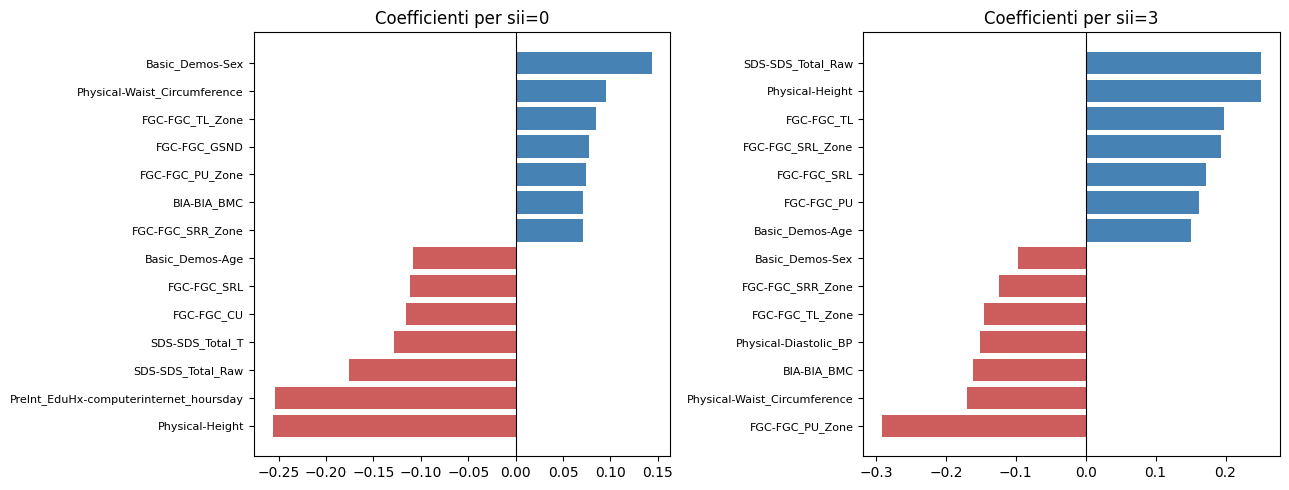

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, k in zip(axes, [0, 3]):
    s = coef_num[f'sii={k}'].sort_values()
    s = pd.concat([s.head(7), s.tail(7)])
    ax.barh(range(len(s)), s.values,
            color=['indianred' if v < 0 else 'steelblue' for v in s.values])
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels([n.replace('num__', '') for n in s.index], fontsize=8)
    ax.axvline(0, color='k', linewidth=.8)
    ax.set_title(f'Coefficienti per sii={k}')
plt.tight_layout(); plt.show()

## 7. Target binario `sii >= 1`

Le guidelines incoraggiano a esplorare target alternativi. Il passaggio da 4 classi a 2
(*nessun problema* vs *qualche livello di uso problematico*) è il più naturale:

- riporta il problema nella forma binaria vista a lezione;
- aggrega le tre classi minoritarie, portando la classe positiva dall'1-19% a circa il 31%;
- corrisponde alla domanda operativa più utile: individuare i ragazzi da sottoporre ad approfondimento.

In [54]:
y_bin = (y >= 1).astype(int)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin, random_state=RANDOM_STATE)
print('Distribuzione:', y_bin.value_counts(normalize=True).round(3).to_dict())

grid_bin = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
    {'clf__C': [0.001, 0.01, 0.1, 1, 10], 'clf__class_weight': [None, 'balanced']},
    scoring='roc_auc', cv=cv, n_jobs=-1).fit(Xb_train, yb_train)

print('Migliori parametri:', grid_bin.best_params_, '| ROC AUC in CV:', round(grid_bin.best_score_, 4))

modello_bin = grid_bin.best_estimator_
prob_bin = modello_bin.predict_proba(Xb_test)[:, 1]
print('ROC AUC sul test:', round(roc_auc_score(yb_test, prob_bin), 4))
print(classification_report(yb_test, modello_bin.predict(Xb_test), digits=3))

Distribuzione: {0: 0.689, 1: 0.311}


Migliori parametri: {'clf__C': 0.01, 'clf__class_weight': 'balanced'} | ROC AUC in CV: 0.7029
ROC AUC sul test: 0.7125
              precision    recall  f1-score   support

           0      0.811     0.692     0.747      1167
           1      0.484     0.642     0.552       525

    accuracy                          0.677      1692
   macro avg      0.648     0.667     0.650      1692
weighted avg      0.710     0.677     0.687      1692



Soglia ottimale: 0.470 -> F1=0.559, precision=0.468, recall=0.693


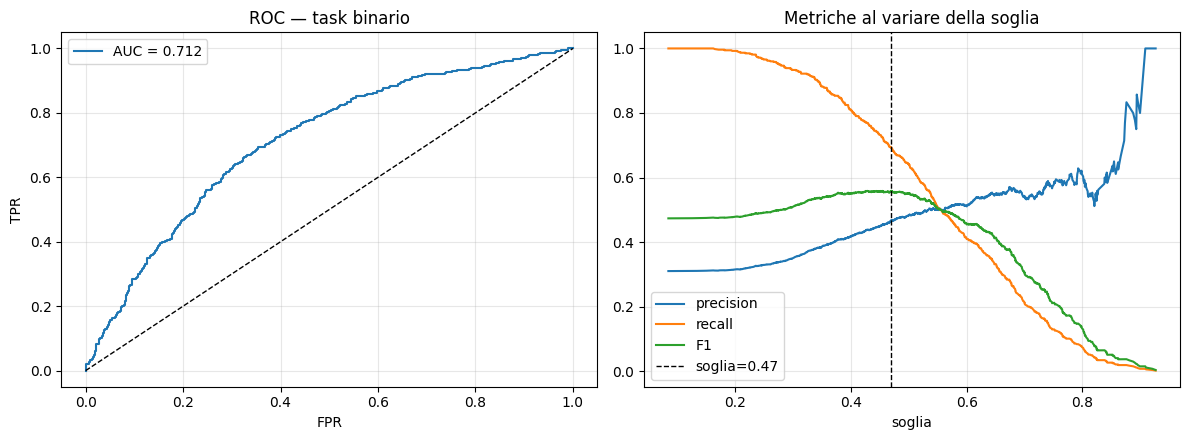

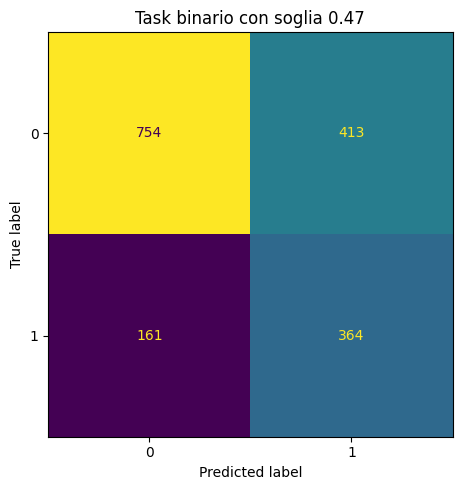

In [55]:
# La soglia 0.5 non e' obbligatoria: si sceglie quella che massimizza l'F1 sulla classe positiva
prec, rec, soglie = precision_recall_curve(yb_test, prob_bin)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
i_best = int(np.argmax(f1_curve[:-1]))
soglia = soglie[i_best]
print(f'Soglia ottimale: {soglia:.3f} -> F1={f1_curve[i_best]:.3f}, '
      f'precision={prec[i_best]:.3f}, recall={rec[i_best]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(yb_test, prob_bin)
axes[0].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC — task binario')
axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(soglie, prec[:-1], label='precision')
axes[1].plot(soglie, rec[:-1], label='recall')
axes[1].plot(soglie, f1_curve[:-1], label='F1')
axes[1].axvline(soglia, color='k', linestyle='--', linewidth=1, label=f'soglia={soglia:.2f}')
axes[1].set_xlabel('soglia'); axes[1].set_title('Metriche al variare della soglia')
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

ConfusionMatrixDisplay.from_predictions(yb_test, (prob_bin >= soglia).astype(int), colorbar=False)
plt.title(f'Task binario con soglia {soglia:.2f}'); plt.tight_layout(); plt.show()

## 8. Confronto diretto: 4 classi vs binarizzazione

Le due formulazioni vengono messe a confronto sulle stesse feature, con lo stesso split e la stessa
procedura di tuning. Per rendere i numeri confrontabili, il modello a 4 classi viene valutato anche
"collassando" le sue predizioni in binario (`sii>=1`): si verifica cioè quanto sarebbe bravo a separare
problema da non problema un modello addestrato a distinguere i quattro livelli.

In [56]:
# Predizioni del modello a 4 classi riportate su scala binaria:
# P(sii>=1) = 1 - P(sii=0), e classe predetta = 0 se predice 0, altrimenti 1
prob_da_multi = 1 - y_prob[:, 0]
pred_da_multi = (y_pred >= 1).astype(int)
y_test_bin = (y_test >= 1).astype(int)

confronto = pd.DataFrame([
    {'formulazione': '4 classi (metriche sulle 4 classi)',
     'ROC AUC': roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'),
     'F1-macro': f1_score(y_test, y_pred, average='macro'),
     'balanced_acc': balanced_accuracy_score(y_test, y_pred),
     'accuracy': accuracy_score(y_test, y_pred)},
    {'formulazione': '4 classi, predizioni collassate in binario',
     'ROC AUC': roc_auc_score(y_test_bin, prob_da_multi),
     'F1-macro': f1_score(y_test_bin, pred_da_multi, average='macro'),
     'balanced_acc': balanced_accuracy_score(y_test_bin, pred_da_multi),
     'accuracy': accuracy_score(y_test_bin, pred_da_multi)},
    {'formulazione': 'binario addestrato direttamente (soglia 0.5)',
     'ROC AUC': roc_auc_score(yb_test, prob_bin),
     'F1-macro': f1_score(yb_test, modello_bin.predict(Xb_test), average='macro'),
     'balanced_acc': balanced_accuracy_score(yb_test, modello_bin.predict(Xb_test)),
     'accuracy': accuracy_score(yb_test, modello_bin.predict(Xb_test))},
    {'formulazione': f'binario diretto (soglia {soglia:.2f})',
     'ROC AUC': roc_auc_score(yb_test, prob_bin),
     'F1-macro': f1_score(yb_test, (prob_bin >= soglia).astype(int), average='macro'),
     'balanced_acc': balanced_accuracy_score(yb_test, (prob_bin >= soglia).astype(int)),
     'accuracy': accuracy_score(yb_test, (prob_bin >= soglia).astype(int))},
]).set_index('formulazione')
print(confronto.round(3).to_string())

                                              ROC AUC  F1-macro  balanced_acc  accuracy
formulazione                                                                           
4 classi (metriche sulle 4 classi)              0.680     0.305         0.395     0.465
4 classi, predizioni collassate in binario      0.687     0.589         0.631     0.599
binario addestrato direttamente (soglia 0.5)    0.712     0.650         0.667     0.677
binario diretto (soglia 0.47)                   0.712     0.642         0.670     0.661


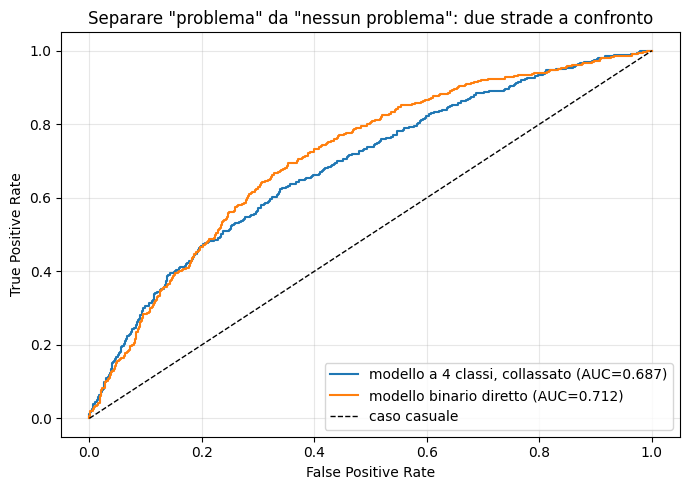

In [57]:
# Le due curve ROC sul medesimo problema binario
plt.figure(figsize=(7, 5))
f1_, t1_, _ = roc_curve(y_test_bin, prob_da_multi)
plt.plot(f1_, t1_, label=f'modello a 4 classi, collassato (AUC={auc(f1_, t1_):.3f})')
f2_, t2_, _ = roc_curve(yb_test, prob_bin)
plt.plot(f2_, t2_, label=f'modello binario diretto (AUC={auc(f2_, t2_):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='caso casuale')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Separare "problema" da "nessun problema": due strade a confronto')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [58]:
# Dove sbaglia il modello a 4 classi: errori vicini (1 livello) vs lontani (2-3 livelli)
dist_err = pd.Series(np.abs(y_test.values - y_pred)).value_counts().sort_index()
dist_err = pd.DataFrame({'n': dist_err, '%': (dist_err / len(y_test) * 100).round(1)})
dist_err.index.name = 'distanza |vero - predetto|'
print(dist_err.to_string())

                              n     %
distanza |vero - predetto|           
0                           787  46.5
1                           445  26.3
2                           266  15.7
3                           194  11.5


**Lettura del confronto.** Il modello binario addestrato direttamente ha un'AUC nettamente superiore a
quella del modello a 4 classi, sia nel confronto multi-classe sia quando le predizioni di quest'ultimo
vengono collassate sullo stesso problema binario. La differenza non dipende quindi solo dal fatto che il
task binario sia "più facile": separare i quattro livelli costringe il modello a stimare confini che i dati
non supportano, e questo peggiora anche la separazione fra problema e non problema.

La tabella delle distanze di errore mostra inoltre che gli errori del modello a 4 classi sono in buona
parte fra livelli adiacenti: la gravità viene colta in modo approssimativo, ma il confine fra "nessun
problema" e "qualche problema" è quello che il modello individua meglio.

Le guidelines chiedono il task multi-classe su `sii`, quindi la versione binaria resta un'analisi
aggiuntiva (esplicitamente incoraggiata), non un sostituto.

## 9. Un secondo target: le ore di internet

Le guidelines invitano a esplorare target alternativi. La scelta ricade su
`PreInt_EduHx-computerinternet_hoursday`, le ore giornaliere dichiarate davanti a uno schermo, binarizzate
in **uso intensivo (>= 2 ore) vs uso contenuto (< 2 ore)**.

**Perché proprio questa variabile**

- È coerente con la domanda di ricerca della competizione, che lega attività fisica e uso di internet: qui
  si inverte la direzione e si chiede se dal profilo fisico e di fitness si possa riconoscere chi passa
  molto tempo online.
- È un dato **osservato direttamente** (ore dichiarate), non il punteggio derivato di un questionario
  psicologico come `sii`: ci si aspetta quindi una relazione più diretta con le variabili disponibili.
- È molto meno sbilanciata: circa il 34% di positivi contro l'1% della classe 3 di `sii`.

**Attenzione al leakage.** `sii` viene escluso dalle feature: deriva dal PCIAT, che misura proprio l'uso
problematico di internet, quindi usarlo per predire le ore online significherebbe dare al modello una
versione del target. Si escludono anche la colonna delle ore (ovviamente) e la sua `Season`.

**Una scelta scartata.** Avevamo valutato anche target come "sovrappeso" (BMI sopra l'85° percentile per
età): un modello del genere raggiunge AUC ~0.99, ma è un risultato privo di significato, perché il BMI è
una funzione deterministica di peso e altezza, che restano fra le feature. È il tipo di target che gonfia
le metriche senza contenuto informativo, e per questo è stato escluso.

### 9.1 Versione multi-classe (4 livelli di ore)

La variabile ha quattro livelli (0, 1, 2, 3+ ore al giorno) e viene analizzata esattamente come `sii`:
stesso split, stessa pipeline, stessa griglia di iperparametri, stesse metriche.

In [59]:
# Target multi-classe: i 4 livelli di ore dichiarate
y_net4 = df['PreInt_EduHx-computerinternet_hoursday']

# Feature: tutte tranne il target, la sua Season e sii (escluso per evitare leakage,
# dato che sii deriva dal PCIAT, questionario sull'uso problematico di internet)
col_escluse = ['id', 'sii', 'PreInt_EduHx-computerinternet_hoursday', 'PreInt_EduHx-Season']
X_net = df.drop(columns=col_escluse)

cat_net = [c for c in X_net.columns if 'Season' in c]
num_net = [c for c in X_net.columns if c not in cat_net]
prep_net = ColumnTransformer([
    ('num', StandardScaler(), num_net),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_net)
])

d4 = y_net4.value_counts().sort_index()
print('Distribuzione dei 4 livelli (ore al giorno):')
print(pd.DataFrame({'n': d4, '%': (d4 / len(y_net4) * 100).round(2)}))
print(f'{X_net.shape[1]} feature usate')

Distribuzione dei 4 livelli (ore al giorno):
                                           n      %
PreInt_EduHx-computerinternet_hoursday             
0                                       3870  45.74
1                                       1730  20.45
2                                       2113  24.98
3                                        747   8.83
46 feature usate


In [60]:
# Split stratificato, come per sii
Xn4_train, Xn4_test, yn4_train, yn4_test = train_test_split(
    X_net, y_net4, test_size=0.2, stratify=y_net4, random_state=RANDOM_STATE)

# Modello di base e versione con pesi di classe, per replicare il confronto fatto su sii
risultati_net = []
lr_net_base = Pipeline([('prep', prep_net),
                        ('clf', LogisticRegression(max_iter=5000,
                                                   random_state=RANDOM_STATE))]).fit(Xn4_train, yn4_train)
lr_net_bal = Pipeline([('prep', prep_net),
                       ('clf', LogisticRegression(max_iter=5000, class_weight='balanced',
                                                  random_state=RANDOM_STATE))]).fit(Xn4_train, yn4_train)
for nome, mod in [('LR base (C=1)', lr_net_base), ('LR balanced (C=1)', lr_net_bal)]:
    risultati_net.append(valuta(nome, mod, Xn4_test, yn4_test, stampa=False))
print(pd.DataFrame(risultati_net).round(3).to_string(index=False))

          modello  accuracy  balanced_acc  f1_macro  roc_auc
    LR base (C=1)     0.546         0.401     0.404    0.717
LR balanced (C=1)     0.478         0.451     0.420    0.705


In [61]:
# Grid search sugli stessi iperparametri usati per sii
grid_net4 = GridSearchCV(
    Pipeline([('prep', prep_net),
              ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
    {'clf__C': griglia_C, 'clf__class_weight': [None, 'balanced']},
    scoring='f1_macro', cv=cv, n_jobs=-1).fit(Xn4_train, yn4_train)

print('Migliori parametri:', grid_net4.best_params_, '| F1-macro in CV:', round(grid_net4.best_score_, 4))

modello_net4 = grid_net4.best_estimator_
yn4_pred = modello_net4.predict(Xn4_test)
yn4_prob = modello_net4.predict_proba(Xn4_test)
C_net = grid_net4.best_params_['clf__C']
cw_net = grid_net4.best_params_['clf__class_weight']
risultati_net.append(valuta(f'LR ottimizzata (C={C_net}, {cw_net})',
                            modello_net4, Xn4_test, yn4_test, stampa=False))
print(classification_report(yn4_test, yn4_pred, digits=3, zero_division=0))

Migliori parametri: {'clf__C': 0.001, 'clf__class_weight': 'balanced'} | F1-macro in CV: 0.4125
              precision    recall  f1-score   support

           0      0.682     0.618     0.648       774
           1      0.397     0.471     0.431       346
           2      0.371     0.210     0.268       423
           3      0.229     0.523     0.319       149

    accuracy                          0.478      1692
   macro avg      0.420     0.456     0.417      1692
weighted avg      0.506     0.478     0.480      1692



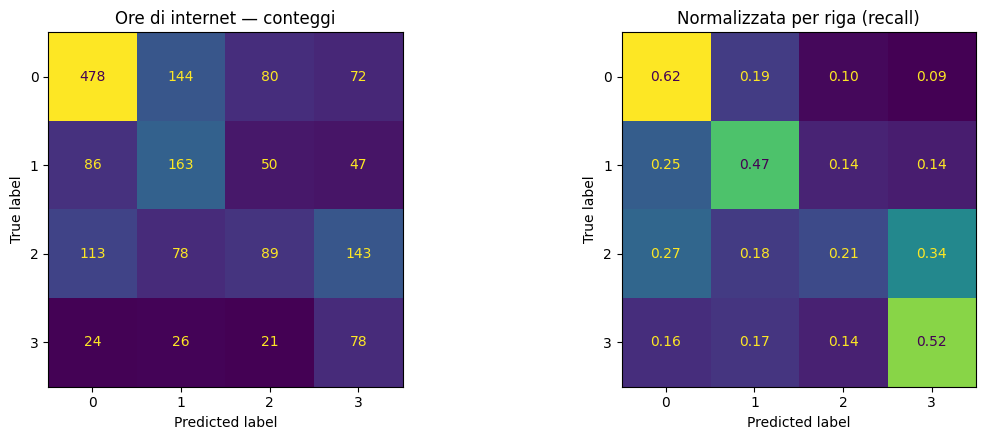

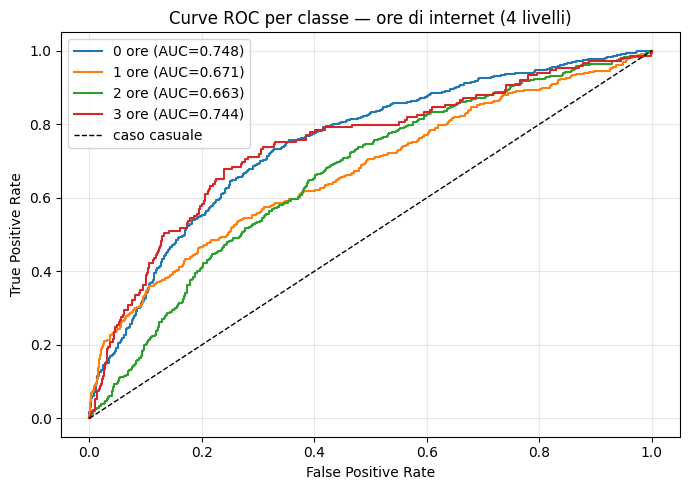

                           modello  accuracy  balanced_acc  f1_macro  roc_auc
                     LR base (C=1)     0.546         0.401     0.404    0.717
                 LR balanced (C=1)     0.478         0.451     0.420    0.705
LR ottimizzata (C=0.001, balanced)     0.478         0.456     0.417    0.706


In [62]:
# Matrici di confusione e curve ROC per classe, come nella sezione 5
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(yn4_test, yn4_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Ore di internet — conteggi')
ConfusionMatrixDisplay.from_predictions(yn4_test, yn4_pred, ax=axes[1], colorbar=False,
                                        normalize='true', values_format='.2f')
axes[1].set_title('Normalizzata per riga (recall)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
for k in range(4):
    fpr, tpr, _ = roc_curve((yn4_test == k).astype(int), yn4_prob[:, k])
    plt.plot(fpr, tpr, label=f'{k} ore (AUC={auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='caso casuale')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curve ROC per classe — ore di internet (4 livelli)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print(pd.DataFrame(risultati_net).round(3).to_string(index=False))

### 9.2 Versione binaria (uso intensivo: >= 2 ore)

Stessa binarizzazione applicata a `sii`: i livelli 2 e 3 vengono accorpati in "uso intensivo",
i livelli 0 e 1 in "uso contenuto". Qui la classe positiva è circa il 34% del campione.

In [63]:
y_net = (y_net4 >= 2).astype(int)
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_net, y_net, test_size=0.2, stratify=y_net, random_state=RANDOM_STATE)
print('quota uso intensivo:', round(y_net.mean(), 3))

grid_net = GridSearchCV(
    Pipeline([('prep', prep_net),
              ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
    {'clf__C': [0.001, 0.01, 0.1, 1, 10], 'clf__class_weight': [None, 'balanced']},
    scoring='roc_auc', cv=cv, n_jobs=-1).fit(Xn_train, yn_train)

print('Migliori parametri:', grid_net.best_params_, '| ROC AUC in CV:', round(grid_net.best_score_, 4))

modello_net = grid_net.best_estimator_
prob_net = modello_net.predict_proba(Xn_test)[:, 1]
pred_net = modello_net.predict(Xn_test)
print('ROC AUC sul test:', round(roc_auc_score(yn_test, prob_net), 4))
print(classification_report(yn_test, pred_net, digits=3))

quota uso intensivo: 0.338
Migliori parametri: {'clf__C': 0.01, 'clf__class_weight': 'balanced'} | ROC AUC in CV: 0.7224
ROC AUC sul test: 0.7333
              precision    recall  f1-score   support

           0      0.795     0.723     0.757      1120
           1      0.539     0.635     0.583       572

    accuracy                          0.693      1692
   macro avg      0.667     0.679     0.670      1692
weighted avg      0.709     0.693     0.698      1692



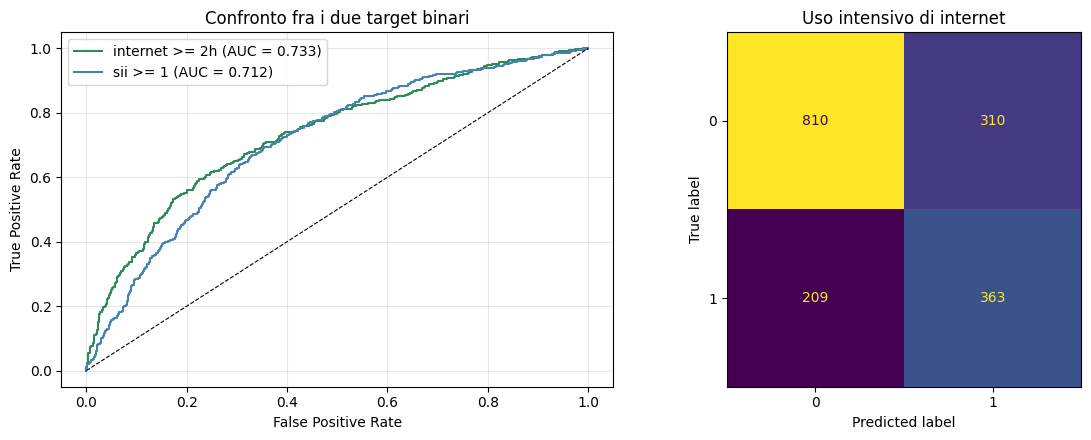

In [64]:
# ROC e matrice di confusione del nuovo task
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr_n, tpr_n, _ = roc_curve(yn_test, prob_net)
axes[0].plot(fpr_n, tpr_n, color='seagreen', label=f'internet >= 2h (AUC = {auc(fpr_n, tpr_n):.3f})')
fpr_s, tpr_s, _ = roc_curve(yb_test, prob_bin)
axes[0].plot(fpr_s, tpr_s, color='steelblue', label=f'sii >= 1 (AUC = {auc(fpr_s, tpr_s):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=.8)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Confronto fra i due target binari'); axes[0].legend(); axes[0].grid(alpha=.3)

ConfusionMatrixDisplay.from_predictions(yn_test, pred_net, ax=axes[1], colorbar=False)
axes[1].set_title('Uso intensivo di internet')
plt.tight_layout(); plt.show()

Odds ratio (per una deviazione standard in piu'):
num__Basic_Demos-Age                 1.344
num__Physical-Height                 1.174
num__CGAS-CGAS_Score                 0.908
num__Physical-Weight                 1.093
num__Physical-BMI                    1.088
num__FGC-FGC_TL_Zone                 0.922
num__BIA-BIA_Activity_Level_num      0.923
num__Physical-Waist_Circumference    1.079
num__FGC-FGC_SRL                     1.071
num__FGC-FGC_GSND                    1.066
num__FGC-FGC_PU_Zone                 1.065
num__FGC-FGC_SRL_Zone                0.942


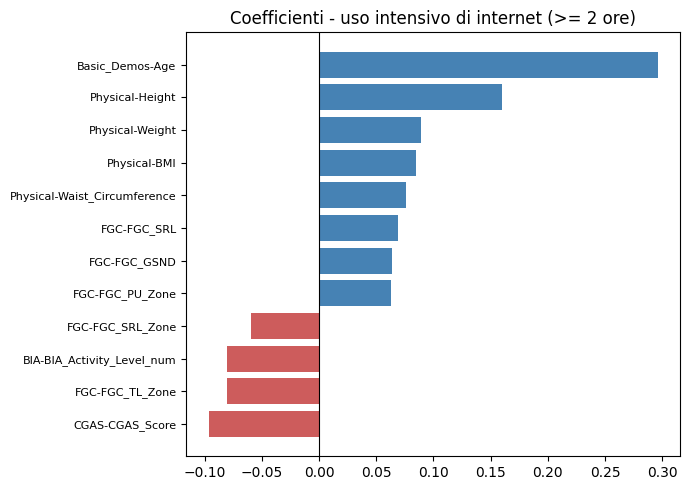

In [65]:
# Interpretazione: odds ratio delle feature numeriche piu' influenti
nomi_net = modello_net.named_steps['prep'].get_feature_names_out()
coef_net = pd.Series(modello_net.named_steps['clf'].coef_[0], index=nomi_net)
coef_net = coef_net[[not n.startswith('cat__') for n in coef_net.index]]
top_net = coef_net.abs().sort_values(ascending=False).head(12).index

print("Odds ratio (per una deviazione standard in piu'):")
print(np.exp(coef_net.loc[top_net]).round(3).to_string())

s_ = coef_net.loc[top_net].sort_values()
plt.figure(figsize=(7, 5))
plt.barh(range(len(s_)), s_.values,
         color=['indianred' if v < 0 else 'steelblue' for v in s_.values])
plt.yticks(range(len(s_)), [n.replace('num__', '') for n in s_.index], fontsize=8)
plt.axvline(0, color='k', linewidth=.8)
plt.title('Coefficienti - uso intensivo di internet (>= 2 ore)')
plt.tight_layout(); plt.show()

### 9.3 Confronto fra tutti i task

In [66]:
confronto_target = pd.DataFrame([
    {'target': 'sii (4 classi)', 'quota classe positiva/rara': '1.0% (classe 3)',
     'ROC AUC': roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'),
     'F1-macro': f1_score(y_test, y_pred, average='macro'),
     'balanced_acc': balanced_accuracy_score(y_test, y_pred)},
    {'target': 'sii >= 1 (binario)', 'quota classe positiva/rara': f'{y_bin.mean()*100:.1f}%',
     'ROC AUC': roc_auc_score(yb_test, prob_bin),
     'F1-macro': f1_score(yb_test, modello_bin.predict(Xb_test), average='macro'),
     'balanced_acc': balanced_accuracy_score(yb_test, modello_bin.predict(Xb_test))},
    {'target': 'internet (4 classi)',
     'quota classe positiva/rara': f'{(y_net4 == 3).mean()*100:.1f}% (classe 3+)',
     'ROC AUC': roc_auc_score(yn4_test, yn4_prob, multi_class='ovr', average='macro'),
     'F1-macro': f1_score(yn4_test, yn4_pred, average='macro'),
     'balanced_acc': balanced_accuracy_score(yn4_test, yn4_pred)},
    {'target': 'internet >= 2h (binario)', 'quota classe positiva/rara': f'{y_net.mean()*100:.1f}%',
     'ROC AUC': roc_auc_score(yn_test, prob_net),
     'F1-macro': f1_score(yn_test, pred_net, average='macro'),
     'balanced_acc': balanced_accuracy_score(yn_test, pred_net)},
]).set_index('target')
print(confronto_target.round(3).to_string())

                         quota classe positiva/rara  ROC AUC  F1-macro  balanced_acc
target                                                                              
sii (4 classi)                      1.0% (classe 3)    0.680     0.305         0.395
sii >= 1 (binario)                            31.1%    0.712     0.650         0.667
internet (4 classi)                8.8% (classe 3+)    0.706     0.417         0.456
internet >= 2h (binario)                      33.8%    0.733     0.670         0.679


**Lettura.** Anche sul nuovo target la versione a 4 classi resta debole, ma meno di quella su `sii`:
i quattro livelli di ore sono molto più equilibrati (nessuna classe sotto l'8%) e il modello riesce a
predirli tutti, invece di collassare sulla maggioranza. Il salto vero arriva comunque con la
binarizzazione.

Il target binario raggiunge un'AUC simile a quella del task `sii >= 1`, ma con F1-macro e
balanced accuracy nettamente più alte: il modello non si limita a ordinare bene i soggetti, riesce anche a
prendere decisioni utili alla soglia di default. La ragione è che le ore dichiarate sono una misura diretta
di comportamento, mentre `sii` è un punteggio costruito a partire da un questionario psicologico, quindi più
distante dalle variabili fisiche a disposizione.

I coefficienti mostrano inoltre che il segnale è in buona parte **anagrafico e di maturazione fisica**
(età, altezza, peso) più che di fitness: i ragazzi più grandi passano più tempo online. È un risultato
onesto da riportare, perché ridimensiona l'idea che siano le variabili di attività fisica a guidare la
predizione.

## 10. Conclusioni

**Risultati.** Sul task a 4 classi la regressione logistica resta vicina al classificatore banale in
accuracy e ha F1-macro e balanced accuracy basse. Le AUC per classe sono comunque sopra 0.5, quindi un po'
di segnale c'è: il problema è trasformarlo in decisioni nette su quattro livelli. Sul task binario l'AUC
sale nettamente, a conferma che la difficoltà sta soprattutto nel distinguere fra i tre livelli di gravità,
non fra "problema" e "non problema".

**Perché questi risultati.**
1. Il target deriva da un questionario psicologico (PCIAT), mentre le feature misurano corpo e attività
   fisica: la relazione è indiretta e mediata da fattori non osservati nel dataset.
2. Le classi 2 e 3 hanno pochissimi esempi, quindi i loro confini non sono stimabili con precisione.
3. La frontiera della regressione logistica è lineare nei log-odds: interazioni ed effetti non monotoni
   (ad esempio un effetto dell'età diverso fra bambini e adolescenti) non sono rappresentabili.

**Cosa aspettarsi dagli altri classificatori del Module 2.** Random Forest e Gradient Boosting, che
modellano interazioni e non linearità, dovrebbero fare meglio sulle classi intermedie. La regressione
logistica resta il riferimento interpretabile con cui confrontarli e il modello che fornisce gli odds ratio
da discutere nel report.